In [75]:
# ------------------------------------------------------------------------
# Script Overview: NB_4_0_SoilConstraints
# ------------------------------------------------------------------------
# This Python script processes spatial soil data using raster and vector datasets from HWSD 2.01  
# in combination with an Excel file containing soil attributes.
#link to HWSD: https://data.apps.fao.org/catalog/iso/ff5c613c-75bb-46a9-a162-bc728059b465

# Main Objectives:
# - Import and align raster (soil grids) and vector (AOI shapefile) data
# - Mask and extract soil data within a specified Area of Interest (AOI)
# - Join raster-derived codes with tabular soil property data
# - Clean, transform, and organize outputs for both topsoil and subsoil layers
#
# Output:
# - Two Excel files containing extracted and formatted soil attributes:
#   1. Topsoil layer
#   2. Subsoil layer

# Author:
# 2025 (...): Mukaratirwa, RutendoTadiwa (NSLD), Agro-Ecological Zoning Programming Specialist, Rutendo.Mukaratirwa@fao.org
# 2025 (July): Asgharinia, Shahla (NSLD), Crop and Soil Spatial Modelling Specialist, shahla.asgharinia@fao.org


In [76]:
# -------------------------------------
# Import required libraries
# -------------------------------------
import os
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from shapely.geometry import mapping
from openpyxl import Workbook


In [77]:
# -------------------------------------
# User Inputs: (Please verify and update paths accordingly)
# -------------------------------------

# Update this path correctly:
working_dir = r"C:\Users\Asgharinia\OneDrive - Food and Agriculture Organization\Documents\PyAEZ\code"
os.chdir(working_dir)

# Define your input file paths here:
raster_path = "HWSD2_RASTER/HWSD2.bil" # Download the raster (.bil) file from the official FAO HWSD source
excel_path = "HWSD2_LAYERS.xlsx"  # source? 
shapefile_path = "UAE_Shapefile/uae_boundaries.shp" # area of interest (AoI)

# -------------------------------------
# Verify input files exist:
# -------------------------------------
input_files = [raster_path, excel_path, shapefile_path]

for file in input_files:
    if os.path.exists(file):
        print(f"✅ File found: {file}")
    else:
        raise FileNotFoundError(f"❌ File missing: {file}")


✅ File found: HWSD2_RASTER/HWSD2.bil
✅ File found: HWSD2_LAYERS.xlsx
✅ File found: UAE_Shapefile/uae_boundaries.shp


Raster loaded successfully with CRS: OGC:CRS84
Shapefile loaded and transformed to raster CRS.


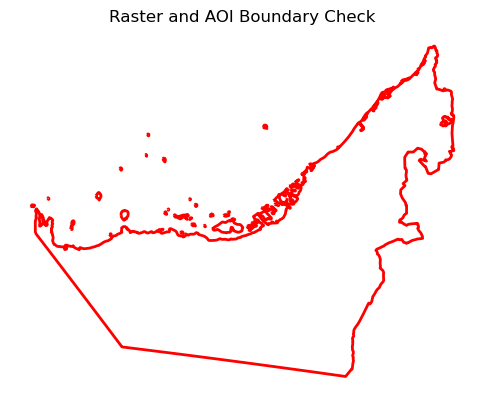

In [88]:

# -------------------------------------
# Step-by-Step Processing with Checks
# -------------------------------------

# Step 1: Load raster and vector data
with rasterio.open(raster_path) as src:
    raster_crs = src.crs
    raster_data = src.read(1)
    raster_nodata = src.nodata

print("Raster loaded successfully with CRS:", raster_crs)

AoI = gpd.read_file(shapefile_path)
if AoI.crs is None:
    AoI = AoI.set_crs(raster_crs)
else:
    AoI = AoI.to_crs(raster_crs)

print("Shapefile loaded and transformed to raster CRS.")

# Test 1: Optional Plot Check
plt.figure(figsize=(6, 6))
plt.imshow(raster_data, cmap="viridis")
AoI.boundary.plot(edgecolor="red", linewidth=2, ax=plt.gca())
plt.title("Raster and AOI Boundary Check")
plt.axis("off")
plt.show()

Raster clipped to AOI boundary.


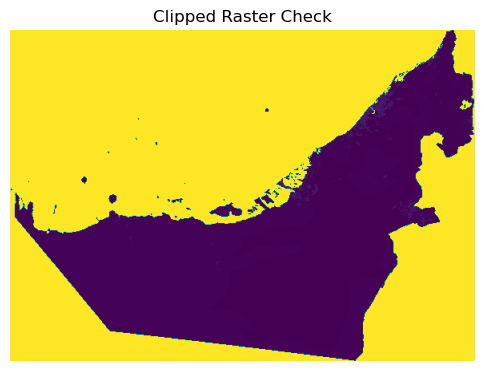

In [79]:
# Step 2: Mask raster with AOI boundary polygon
with rasterio.open(raster_path) as src:
    shapes = [mapping(geom) for geom in uae_boundary.geometry]
    clipped_raster, clipped_transform = mask(src, shapes, crop=True, nodata=raster_nodata)
    clipped_raster = clipped_raster[0]

print("Raster clipped to AOI boundary.")

# test 2: Optional visual check of the clipped raster
plt.figure(figsize=(6, 6))
plt.imshow(clipped_raster, cmap='viridis')
plt.title("Raster clipped to AOI boundary")
plt.axis("off")
plt.show()

In [87]:

# Step 3: Extract raster values inside AOI
rows, cols = np.where(clipped_raster != raster_nodata)
xs, ys = rasterio.transform.xy(clipped_transform, rows, cols)
values = clipped_raster[rows, cols]

extracted_df = pd.DataFrame({"HWSD2_SMU_ID": values, "x": xs, "y": ys})
unique_values = extracted_df.drop_duplicates(subset=["HWSD2_SMU_ID"])

print("Unique soil mapping units extracted:", len(unique_values))

print("All unique HWSD2_SMU_ID values:")
for val in unique_values["HWSD2_SMU_ID"]:
    print(val)


Unique soil mapping units extracted: 11
All unique HWSD2_SMU_ID values:
3515
7001
3580
3043
3595
3620
3592
3624
3539
3548
3549


In [81]:

# Step 4: Load and filter soil attribute Excel file correctly
soil_attributes = pd.read_excel(excel_path, sheet_name="HWSD2_LAYERS")  # specify sheet_name if necessary
soil_data = soil_attributes[soil_attributes['HWSD2_SMU_ID'].isin(unique_values['HWSD2_SMU_ID'])]

print("Soil attributes loaded and filtered by raster values.")




Soil attributes loaded and filtered by raster values.


In [82]:

# Step 5: Clean and subset data
soil_data = soil_data.fillna(0)
soil_data = soil_data[soil_data['TEXTURE_USDA'] != 0]
soil_data = soil_data.loc[soil_data.groupby(['HWSD2_SMU_ID', 'LAYER'])['SHARE'].idxmax()]

print("Data cleaned and duplicates removed.")


Data cleaned and duplicates removed.


In [83]:

# Step 6: Replace texture numeric codes with descriptions
texture_lookup = pd.DataFrame({
    "CODE": range(1, 14),
    "VALUE": ["Clay (heavy)", "Silty clay", "Clay (light)", "Silty clay loam",
              "Clay loam", "Silt", "Silt loam", "Sandy clay", "Loam",
              "Sandy clay loam", "Sandy loam", "Loamy sand", "Sand"]
})
soil_data = soil_data.merge(texture_lookup, left_on="TEXTURE_USDA", right_on="CODE", how="left")
soil_data['TEXTURE_USDA'] = soil_data['VALUE']
soil_data.drop(columns=['CODE', 'VALUE'], inplace=True)

print("Texture descriptions assigned.")


Texture descriptions assigned.


In [84]:
# Step 7: Binary transformation for ADD_PROP
soil_data['ADD_PROP'] = (soil_data['ADD_PROP'] == 3).astype(int)

print("Binary transformation completed: 'ADD_PROP' is now 1 where value was 3, and 0 elsewhere.")

Binary transformation completed: 'ADD_PROP' is now 1 where value was 3, and 0 elsewhere.


In [85]:

# Step 8: Column reorder and rename
column_order = ["HWSD2_SMU_ID", "TEXTURE_USDA", "ORG_CARBON", "PH_WATER", "TEB", "BSAT",
                "CEC_SOIL", "CEC_CLAY", "ROOT_DEPTH", "PHASE1", "PHASE2", "ROOTS", "IL",
                "DRAINAGE", "ESP", "ELEC_COND", "TCARBON_EQ", "GYPSUM", "COARSE",
                "ADD_PROP", "LAYER", "SHARE"]
soil_data = soil_data[column_order]
soil_data.columns = ["CODE", "TXT", "OC", "pH", "TEB", "BS", "CEC_soil", "CEC_clay", "RSD",
                     "SPR", "SPH", "ROOTS", "IL", "DRG", "ESP", "EC", "CCB", "GYP", "GRC",
                     "VSP", "LAYER", "SHARE"]
print("Columns reordered and renamed.")


Columns reordered and renamed.


In [86]:
# Step 9: Export soil attributes to Excel by layer group

def create_soil_workbook(data, layers, filename):
    wb = Workbook()
    ws = wb.active
    wb.remove(ws)  # Remove default sheet
    
    for layer in layers:
        layer_data = data[data['LAYER'] == layer]
        if not layer_data.empty:
            ws = wb.create_sheet(title=layer)
            ws.append(list(layer_data.columns))
            for row in layer_data.itertuples(index=False):
                ws.append(list(row))
    
    wb.save(filename)
# Create Topsoil (D1-D3) and Subsoil (D4-D7) files
top_layers = ['D1', 'D2', 'D3']
sub_layers = ['D4', 'D5', 'D6', 'D7']

create_soil_workbook(soil_data, top_layers, "Top_Soil_Layers.xlsx")
create_soil_workbook(soil_data, sub_layers, "Sub_Soil_Layers.xlsx")

print("Two Excel workbooks have been created: one for topsoil layers (D1–D3) and one for subsoil layers (D4–D7).")

Two Excel workbooks have been created: one for topsoil layers (D1–D3) and one for subsoil layers (D4–D7).
